# 03 Evaluate Results

Ovaj notebook evaluira modele istrenirane u `02_train_models.ipynb`.

Fokus je na dve vrste provere:

- **Lokalna derivative provera**: koliko dobro model pogađa `xdot = f(x)` na test tačkama.
- **Autoregresivni rollout test**: model dobije samo početno stanje `x0`, zatim sam proizvodi `x1, x2, ...` tako što se svako predviđeno stanje vraća nazad kao sledeći ulaz.

Autoregresivni test je važniji za dinamiku: mali one-step error ne znači nužno da će simulacija ostati dobra kroz mnogo koraka.

## 1. Importi i konfiguracija

Koristi isti `SYSTEM_NAME`, dimenzije modela i hiperparametre kao u trening notebooku. Ako promeniš sistem ili arhitekturu u `02_train_models.ipynb`, isto promeni i ovde pre učitavanja checkpoint-a.

Za ovaj notebook je potreban ispravan PyTorch kernel: **Python (masters_torch312)**.

In [50]:
from pathlib import Path
import sys
import numpy as np

# Let the notebook import the local package whether Jupyter starts in the
# repository root or inside the notebooks/ directory.
REPO_ROOT = Path.cwd() if (Path.cwd() / "stable_icnn_physics").exists() else Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Jupyter kernels keep imported modules in memory. If package code changed
# while the kernel was alive, clear the local package so imports see the
# latest files from disk.
for module_name in list(sys.modules):
    if module_name == "stable_icnn_physics" or module_name.startswith("stable_icnn_physics."):
        del sys.modules[module_name]

try:
    import torch
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "PyTorch is not installed in this notebook kernel. "
        "In VS Code/Jupyter, switch the kernel to 'Python (masters_torch312)', "
        "or install dependencies with: pip install -r requirements.txt"
    ) from exc
except ImportError as exc:
    raise ImportError(
        "PyTorch exists in this kernel but failed to load. "
        "Switch the notebook kernel to 'Python (masters_torch312)'."
    ) from exc

from stable_icnn_physics import BaselineDynamicsMLP, DampedPendulum, MassSpringDamper, VanDerPolOscillator
from stable_icnn_physics.data import dataset_path, load_dataset, tensor_dataset
from stable_icnn_physics.eval import (
    autoregressive_rollout_model,
    lyapunov_decrease_values,
    rollout_error,
    rollout_system,
)
from stable_icnn_physics.models import build_stable_model
from stable_icnn_physics.plotting import plot_lyapunov_contours, plot_vector_field
from stable_icnn_physics.train import evaluate_derivative_mse

CACHE_DIR = REPO_ROOT / "data/cache"
OUTPUT_DIR = REPO_ROOT / "outputs"
SEED = 0
SYSTEM_NAME = "oscillator"
N_TEST = 1000

# Keep this system consistent with the dataset generated in 01_generate_data.ipynb.
#system = MassSpringDamper(mass=1.0, damping=0.3, stiffness=1.0)
# system = DampedPendulum(n_links=1, friction=0.3, gravity=9.81)
SYSTEM_NAME = "vanderpol_mu1"
system = VanDerPolOscillator(mu=1.0)

HIDDEN = 100
DEPTH = 2
LYAPUNOV_HIDDEN = 60
LYAPUNOV_EPS = 0.01
ALPHA = 1e-3

ROLLOUT_STEPS = 350
DT = 0.02
N_ROLLOUTS = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(SEED)
np.random.seed(SEED)

print("Repo root:", REPO_ROOT)
print("Torch:", torch.__version__)
print("Device:", DEVICE)
print("System:", SYSTEM_NAME)
print("State dimension:", system.state_dim)

Repo root: /media/ognjen/T7 Shield/DOCs, PDFs/018 Master/DeepLearningFTN
Torch: 2.9.1+cpu
Device: cpu
System: vanderpol_mu1
State dimension: 2


## 2. Učitavanje test podataka i checkpoint-a

Ova ćelija učitava:

- test dataset iz `data/cache/`,
- stabilni ICNN dynamics checkpoint,
- baseline MLP checkpoint.

Ako checkpoint ne postoji, prvo pokreni `02_train_models.ipynb`.

In [51]:
test_path = dataset_path(CACHE_DIR, SYSTEM_NAME, "test", N_TEST, SEED)
stable_ckpt_path = OUTPUT_DIR / f"{SYSTEM_NAME}_stable.pt"
baseline_ckpt_path = OUTPUT_DIR / f"{SYSTEM_NAME}_baseline.pt"

missing = [p for p in [test_path, stable_ckpt_path, baseline_ckpt_path] if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required files:\n"
        + "\n".join(str(p) for p in missing)
        + "\nRun 01_generate_data.ipynb and 02_train_models.ipynb first."
    )

x_test, y_test = load_dataset(test_path)
test_ds = tensor_dataset(x_test, y_test)
dim = x_test.shape[1]

stable_model = build_stable_model(
    dim,
    hidden=HIDDEN,
    depth=DEPTH,
    lyapunov_hidden=LYAPUNOV_HIDDEN,
    lyapunov_eps=LYAPUNOV_EPS,
    alpha=ALPHA,
)
baseline_model = BaselineDynamicsMLP(dim=dim, hidden=HIDDEN, depth=DEPTH)

stable_model.load_state_dict(torch.load(stable_ckpt_path, map_location=DEVICE)["model_state"])
baseline_model.load_state_dict(torch.load(baseline_ckpt_path, map_location=DEVICE)["model_state"])
stable_model.to(DEVICE).eval()
baseline_model.to(DEVICE).eval()

print("test dataset:", x_test.shape, y_test.shape)
print("loaded stable checkpoint:  ", stable_ckpt_path)
print("loaded baseline checkpoint:", baseline_ckpt_path)


test dataset: (1000, 2) (1000, 2)
loaded stable checkpoint:   /media/ognjen/T7 Shield/DOCs, PDFs/018 Master/DeepLearningFTN/outputs/vanderpol_mu1_stable.pt
loaded baseline checkpoint: /media/ognjen/T7 Shield/DOCs, PDFs/018 Master/DeepLearningFTN/outputs/vanderpol_mu1_baseline.pt


## 3. Lokalna derivative metrika

Prvo merimo MSE za `x -> xdot` na test skupu. Ovo je ista vrsta greške koju optimizujemo tokom treninga.

Ova metrika je korisna, ali nije dovoljna: model može lokalno dobro da pogađa izvode, a da pri dugom rollout-u akumulira grešku.

stable derivative MSE:   0.01922501754760742
baseline derivative MSE: 0.004656230926513672


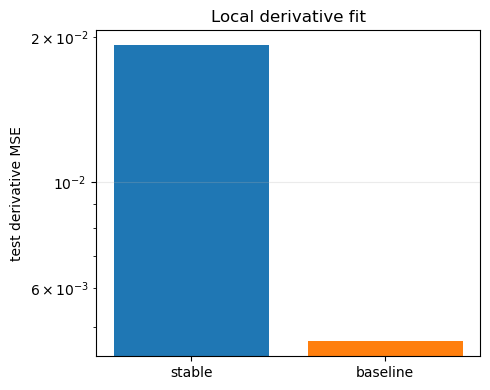

In [52]:
stable_derivative_mse = evaluate_derivative_mse(stable_model, test_ds, device=DEVICE)
baseline_derivative_mse = evaluate_derivative_mse(baseline_model, test_ds, device=DEVICE)

print("stable derivative MSE:  ", stable_derivative_mse)
print("baseline derivative MSE:", baseline_derivative_mse)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
labels = ["stable", "baseline"]
values = [stable_derivative_mse, baseline_derivative_mse]
ax.bar(labels, values, color=["tab:blue", "tab:orange"])
ax.set_yscale("log")
ax.set_ylabel("test derivative MSE")
ax.set_title("Local derivative fit")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

## 4. Scatter: tačan izvod vs predviđen izvod

Svaka tačka poredi jednu komponentu pravog izvoda i predviđenog izvoda. Idealno, tačke prate isprekidanu dijagonalu.

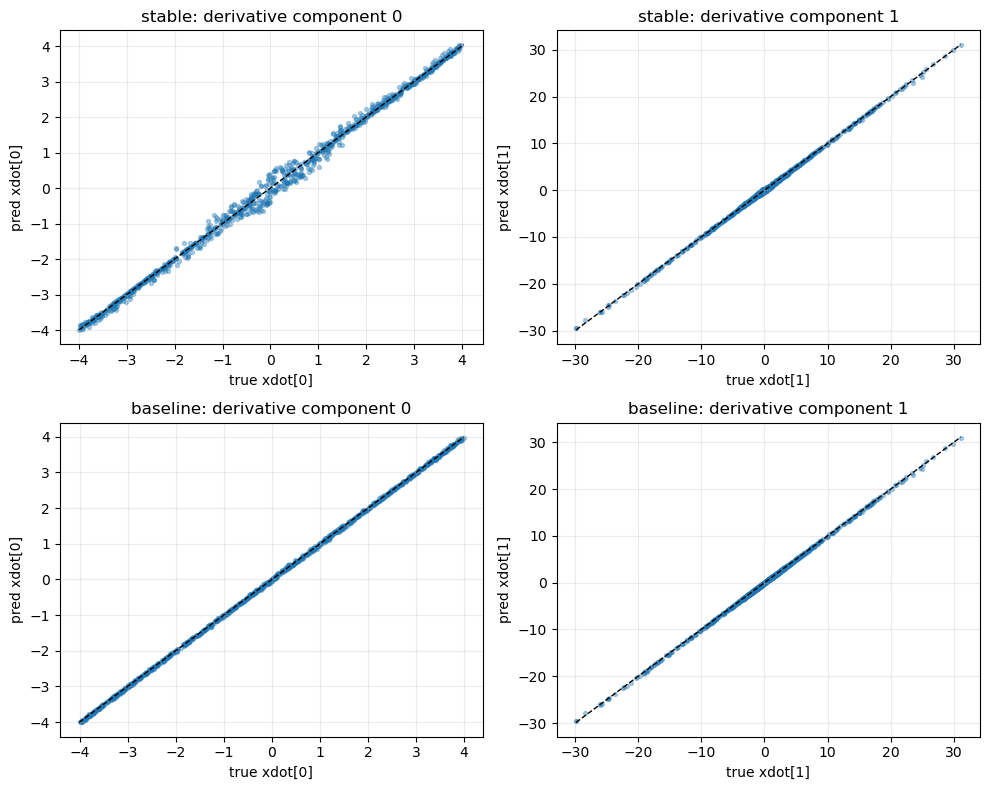

In [53]:
def predict_numpy(model, x_np, batch_size=2048):
    model.eval()
    preds = []
    with torch.enable_grad():
        for start in range(0, len(x_np), batch_size):
            xb = torch.from_numpy(x_np[start:start + batch_size]).to(DEVICE)
            preds.append(model(xb).detach().cpu().numpy())
    return np.concatenate(preds, axis=0)

stable_pred = predict_numpy(stable_model, x_test)
baseline_pred = predict_numpy(baseline_model, x_test)

fig, axes = plt.subplots(2, dim, figsize=(5 * dim, 8), squeeze=False)
for row, (name, pred) in enumerate([("stable", stable_pred), ("baseline", baseline_pred)]):
    for j in range(dim):
        ax = axes[row, j]
        ax.scatter(y_test[:, j], pred[:, j], s=8, alpha=0.35)
        lo = min(y_test[:, j].min(), pred[:, j].min())
        hi = max(y_test[:, j].max(), pred[:, j].max())
        ax.plot([lo, hi], [lo, hi], color="black", lw=1, ls="--")
        ax.set_xlabel(f"true xdot[{j}]")
        ax.set_ylabel(f"pred xdot[{j}]")
        ax.set_title(f"{name}: derivative component {j}")
        ax.grid(alpha=0.25)
plt.tight_layout()

## 5. Autoregresivni rollout test

Ovo je centralni test za dinamiku.

Postupak:

1. Izaberemo početna stanja `x0`.
2. Pravu dinamiku simuliramo RK4 integratorom iz poznatog fizičkog modela.
3. Naučenom modelu damo samo `x0`.
4. Model predvidi izvod, RK4 napravi sledeće stanje, i to predviđeno stanje se vraća modelu kao novi ulaz.
5. Ponavljamo kroz mnogo koraka.

U pseudokodu:

```text
x_pred[0] = x0
for t in range(T):
    x_pred[t + 1] = RK4_step(model, x_pred[t], dt)
```

To je autoregresivno zato što model ne dobija stvarno stanje u narednim koracima, već sopstvenu prethodnu predikciju.

In [54]:
x0 = system.sample_states(N_ROLLOUTS, split="test", seed=SEED + 123)
true_traj = rollout_system(system, x0, steps=ROLLOUT_STEPS, dt=DT)
stable_traj = autoregressive_rollout_model(
    stable_model,
    x0,
    steps=ROLLOUT_STEPS,
    dt=DT,
    device=DEVICE,
    wrap_fn=system.wrap_state,
)
baseline_traj = autoregressive_rollout_model(
    baseline_model,
    x0,
    steps=ROLLOUT_STEPS,
    dt=DT,
    device=DEVICE,
    wrap_fn=system.wrap_state,
)

stable_error = rollout_error(system, true_traj, stable_traj)
baseline_error = rollout_error(system, true_traj, baseline_traj)
time = np.arange(ROLLOUT_STEPS + 1) * DT

print("true trajectory shape:    ", true_traj.shape)
print("stable trajectory shape:  ", stable_traj.shape)
print("baseline trajectory shape:", baseline_traj.shape)
print("final stable mean error:  ", stable_error[-1].mean())
print("final baseline mean error:", baseline_error[-1].mean())

true trajectory shape:     (351, 64, 2)
stable trajectory shape:   (351, 64, 2)
baseline trajectory shape: (351, 64, 2)
final stable mean error:   1.1087266
final baseline mean error: 0.016696876


## 6. Rollout greška kroz vreme

Ovde se vidi akumulacija greške. Ako baseline lokalno izgleda dobro, ali mu se rollout brzo pogoršava, to je tipičan znak da nema dobru globalnu/stabilnu strukturu dinamike.

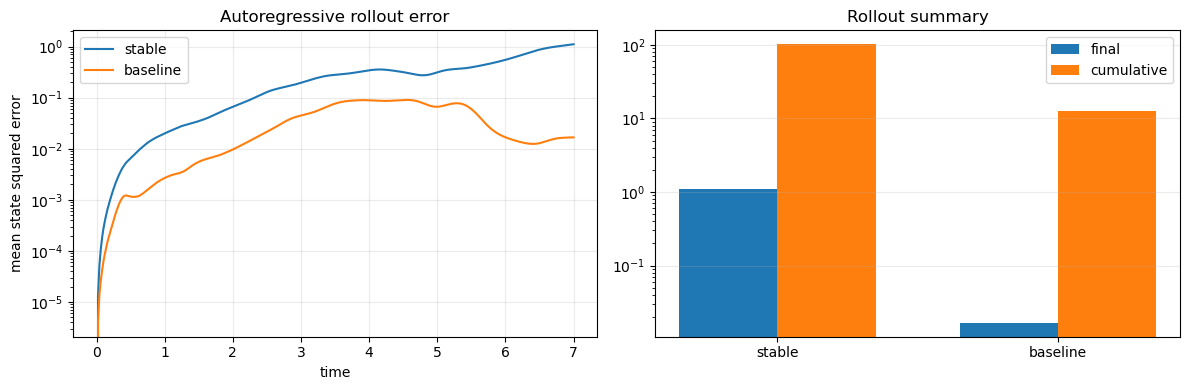

In [55]:
stable_mean_error = stable_error.mean(axis=1)
baseline_mean_error = baseline_error.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(time, stable_mean_error, label="stable")
axes[0].plot(time, baseline_mean_error, label="baseline")
axes[0].set_yscale("log")
axes[0].set_xlabel("time")
axes[0].set_ylabel("mean state squared error")
axes[0].set_title("Autoregressive rollout error")
axes[0].legend()
axes[0].grid(alpha=0.25)

final_errors = [stable_mean_error[-1], baseline_mean_error[-1]]
cumulative_errors = [stable_mean_error.sum(), baseline_mean_error.sum()]
xpos = np.arange(2)
width = 0.35
axes[1].bar(xpos - width / 2, final_errors, width, label="final")
axes[1].bar(xpos + width / 2, cumulative_errors, width, label="cumulative")
axes[1].set_xticks(xpos, ["stable", "baseline"])
axes[1].set_yscale("log")
axes[1].set_title("Rollout summary")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)
plt.tight_layout()

## 7. Jedna trajektorija: fazni prostor i stanje kroz vreme

Sada gledamo jednu početnu tačku detaljno. Za oscilator, fazni prostor je `position` prema `velocity`; za klatno je `theta` prema `omega`.

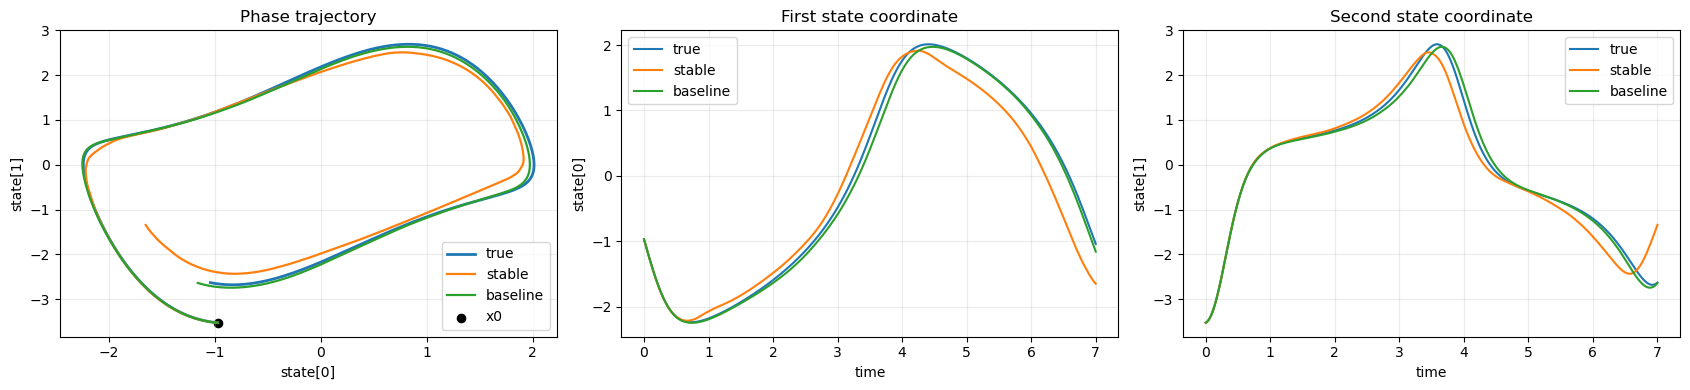

In [56]:
traj_id = 0

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(true_traj[:, traj_id, 0], true_traj[:, traj_id, 1], label="true", lw=2)
axes[0].plot(stable_traj[:, traj_id, 0], stable_traj[:, traj_id, 1], label="stable", lw=1.6)
axes[0].plot(baseline_traj[:, traj_id, 0], baseline_traj[:, traj_id, 1], label="baseline", lw=1.6)
axes[0].scatter([x0[traj_id, 0]], [x0[traj_id, 1]], c="black", s=35, label="x0")
axes[0].set_xlabel("state[0]")
axes[0].set_ylabel("state[1]")
axes[0].set_title("Phase trajectory")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(time, true_traj[:, traj_id, 0], label="true")
axes[1].plot(time, stable_traj[:, traj_id, 0], label="stable")
axes[1].plot(time, baseline_traj[:, traj_id, 0], label="baseline")
axes[1].set_xlabel("time")
axes[1].set_ylabel("state[0]")
axes[1].set_title("First state coordinate")
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[2].plot(time, true_traj[:, traj_id, 1], label="true")
axes[2].plot(time, stable_traj[:, traj_id, 1], label="stable")
axes[2].plot(time, baseline_traj[:, traj_id, 1], label="baseline")
axes[2].set_xlabel("time")
axes[2].set_ylabel("state[1]")
axes[2].set_title("Second state coordinate")
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.tight_layout()

## 8. Vektorska polja i Lyapunov konture

Za 2D sisteme možemo direktno prikazati naučeno vektorsko polje. Stabilni model dodatno ima Lyapunov funkciju `V(x)`, čije konture prikazuju geometriju stabilnosti koju je model naučio.

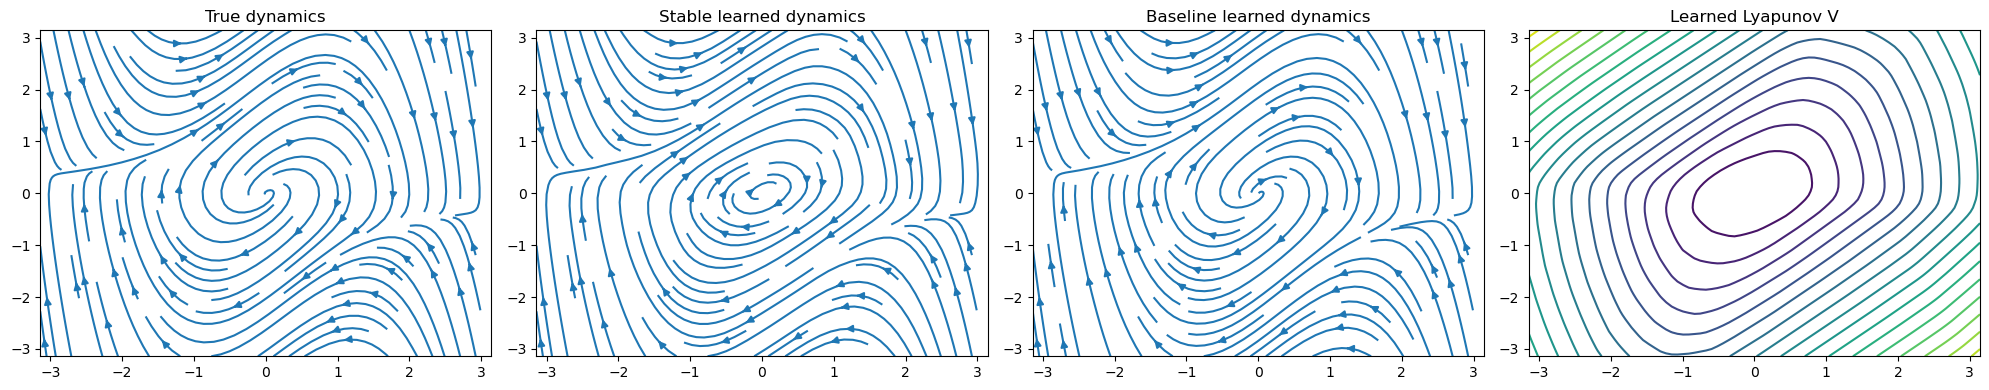

In [57]:
if dim != 2:
    print("Vector-field visualization is only implemented for 2D systems.")
else:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    plot_vector_field(system, model=None, ax=axes[0], title="True dynamics")
    plot_vector_field(system, model=stable_model, ax=axes[1], title="Stable learned dynamics")
    plot_vector_field(system, model=baseline_model, ax=axes[2], title="Baseline learned dynamics")
    plot_lyapunov_contours(stable_model, ax=axes[3], title="Learned Lyapunov V")
    plt.tight_layout()

## 9. Lyapunov decrease dijagnostika

Za stabilni model proveravamo residual:

```text
grad V(x)^T f(x) + alpha V(x)
```

Po konstrukciji modela ova vrednost treba da bude manja ili jednaka nuli, osim sitne numeričke tolerancije.

max gradV*f + alpha*V: 3.0100346e-06
mean residual: -22.967005
fraction <= 1e-5: 1.0
V min/max: 0.0024698277 51.858303


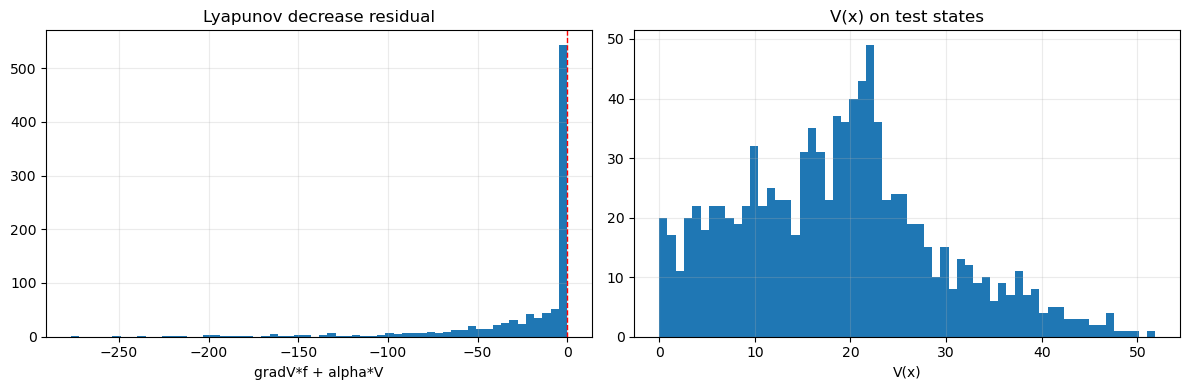

In [58]:
decrease = lyapunov_decrease_values(stable_model, x_test[: min(1024, len(x_test))], device=DEVICE).ravel()

with torch.enable_grad():
    xt = torch.from_numpy(x_test[: min(1024, len(x_test))]).to(DEVICE)
    V_values = stable_model.V(xt).detach().cpu().numpy().ravel()

print("max gradV*f + alpha*V:", decrease.max())
print("mean residual:", decrease.mean())
print("fraction <= 1e-5:", np.mean(decrease <= 1e-5))
print("V min/max:", V_values.min(), V_values.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(decrease, bins=60)
axes[0].axvline(0.0, color="red", lw=1, ls="--")
axes[0].set_title("Lyapunov decrease residual")
axes[0].set_xlabel("gradV*f + alpha*V")
axes[0].grid(alpha=0.25)

axes[1].hist(V_values, bins=60)
axes[1].set_title("V(x) on test states")
axes[1].set_xlabel("V(x)")
axes[1].grid(alpha=0.25)
plt.tight_layout()

## 10. Animacija autoregresivnog rollout-a za oscilator

Za oscilator možemo animirati jednu trajektoriju. Crna tačka je prava simulacija, plava stabilni model, narandžasta baseline.

Ako baseline ode daleko od prave trajektorije, to će biti vidljivo kao razilaženje tačaka kroz vreme.

In [59]:
from IPython.display import HTML, display
from matplotlib import animation

if not isinstance(system, MassSpringDamper):
    print("Animation is configured for MassSpringDamper. Current system:", type(system).__name__)
else:
    anim_id = 0
    frame_stride = max(1, len(time) // 180)
    frames = np.arange(0, len(time), frame_stride)

    fig, ax = plt.subplots(figsize=(8, 2.8))
    all_pos = np.concatenate([
        true_traj[:, anim_id, 0],
        stable_traj[:, anim_id, 0],
        baseline_traj[:, anim_id, 0],
    ])
    lim = max(2.2, float(np.max(np.abs(all_pos))) * 1.15)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-0.8, 0.8)
    ax.set_yticks([])
    ax.set_xlabel("position")
    ax.set_title("Autoregressive rollout: true vs stable vs baseline")
    ax.grid(axis="x", alpha=0.2)
    ax.axvline(0.0, color="gray", ls="--", lw=1)

    true_marker, = ax.plot([], [], "o", color="black", markersize=9, label="true")
    stable_marker, = ax.plot([], [], "o", color="tab:blue", markersize=8, label="stable")
    baseline_marker, = ax.plot([], [], "o", color="tab:orange", markersize=8, label="baseline")
    time_text = ax.text(0.02, 0.86, "", transform=ax.transAxes)
    ax.legend(loc="lower right")

    def init():
        for marker in [true_marker, stable_marker, baseline_marker]:
            marker.set_data([], [])
        time_text.set_text("")
        return true_marker, stable_marker, baseline_marker, time_text

    def update(frame_index):
        frame = frames[frame_index]
        true_marker.set_data([true_traj[frame, anim_id, 0]], [0.25])
        stable_marker.set_data([stable_traj[frame, anim_id, 0]], [0.0])
        baseline_marker.set_data([baseline_traj[frame, anim_id, 0]], [-0.25])
        time_text.set_text(f"t = {time[frame]:.2f}s")
        return true_marker, stable_marker, baseline_marker, time_text

    anim = animation.FuncAnimation(
        fig,
        update,
        init_func=init,
        frames=len(frames),
        interval=35,
        blit=True,
    )
    plt.close(fig)
    display(HTML(anim.to_jshtml()))

Animation is configured for MassSpringDamper. Current system: VanDerPolOscillator


## 11. Kratak numerički rezime

Ova ćelija sabira lokalnu derivative grešku i autoregresivnu rollout grešku. Za izveštaj obično koristi:

- derivative MSE,
- final rollout error,
- cumulative rollout error,
- Lyapunov residual max/fraction.

In [60]:
summary = {
    "stable_derivative_mse": stable_derivative_mse,
    "baseline_derivative_mse": baseline_derivative_mse,
    "stable_final_rollout_error": float(stable_mean_error[-1]),
    "baseline_final_rollout_error": float(baseline_mean_error[-1]),
    "stable_cumulative_rollout_error": float(stable_mean_error.sum()),
    "baseline_cumulative_rollout_error": float(baseline_mean_error.sum()),
    "stable_lyapunov_residual_max": float(decrease.max()),
    "stable_lyapunov_fraction_ok": float(np.mean(decrease <= 1e-5)),
}

for key, value in summary.items():
    print(f"{key:36s} {value:.6g}")

stable_derivative_mse                0.019225
baseline_derivative_mse              0.00465623
stable_final_rollout_error           1.10873
baseline_final_rollout_error         0.0166969
stable_cumulative_rollout_error      101.716
baseline_cumulative_rollout_error    12.6457
stable_lyapunov_residual_max         3.01003e-06
stable_lyapunov_fraction_ok          1
